In [1]:
import numpy as np
import os
import sys
import tkinter as tk
import tifffile
import src.utils.ingaas_processing as ingaas_processing
from src import stitching
from src.stitching import helpers
import cv2
from matplotlib import pyplot as plt
from tkinter import filedialog
import scipy
#import toml_rs as tml
import io

root = tk.Tk()
root.withdraw()
root.call('wm', 'attributes', '.', '-topmost', True)

width, height = 640, 512

<tifffile.TiffPages @655368> invalid page offset 2253684482


1145
[   0    3    6 ... 3426 3429 3432]
[   1    4    7 ... 3427 3430 3433]
[   2    5    8 ... 3428 3431 3434]


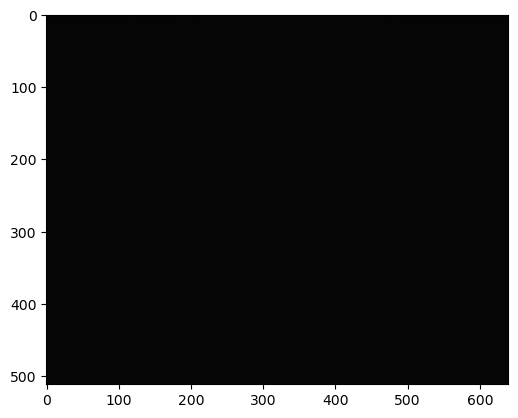

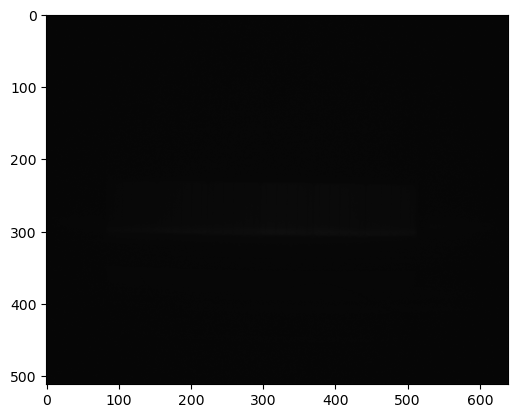

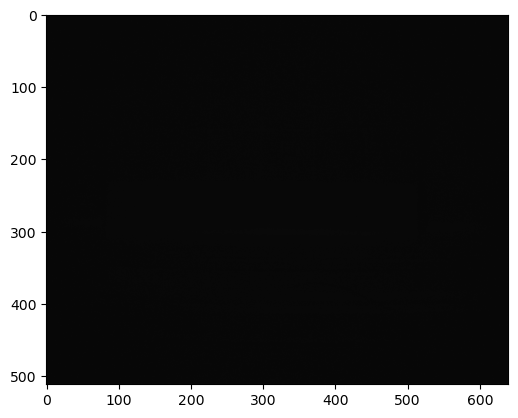

In [ ]:
mod_freq = 50
fps = 150

im_path = filedialog.askopenfilename(title='Select image to process')
images = np.array(tifffile.imread(im_path))

1145
[   0    3    6 ... 3426 3429 3432]
[   1    4    7 ... 3427 3430 3433]
[   2    5    8 ... 3428 3431 3434]


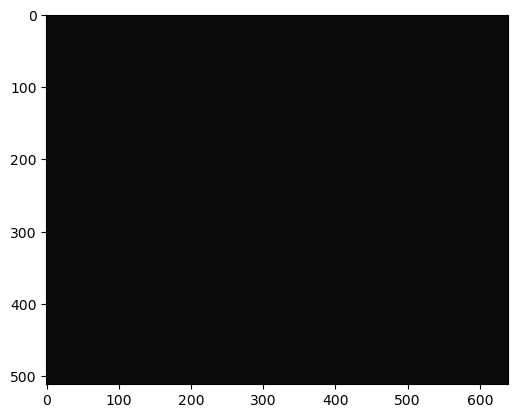

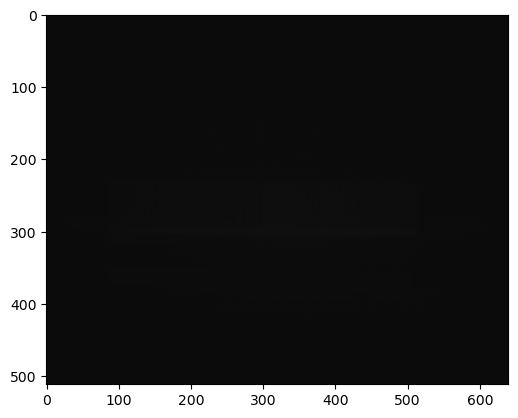

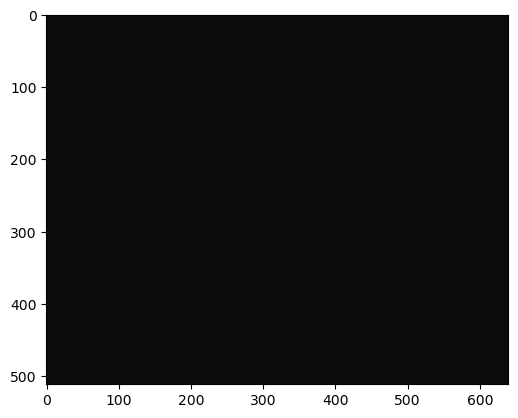

In [10]:
vmin = images.min()
vmax = images.max()
stretched = ingaas_processing.lin_stretch_img(images, low_prc=0.5, high_prc=99.5)

temp = int(len(images)/3)
print(temp)
ind_1 = np.arange(0, temp*3, 3)
ind_2 = np.arange(1, temp*3, 3)
ind_3 = np.arange(2, temp*3, 3)
print(ind_1)
print(ind_2)
print(ind_3)

seq_1 = stretched[ind_1]
seq_2 = stretched[ind_2]
seq_3 = stretched[ind_3]

index = 300
plt.imshow(seq_1[index], cmap='gray', vmin=vmin, vmax=vmax)
plt.show()
plt.imshow(seq_2[index], cmap='gray', vmin=vmin, vmax=vmax)
plt.show()
plt.imshow(seq_3[index], cmap='gray', vmin=vmin, vmax=vmax)
plt.show()

In [ ]:
cal_path = "data/calibration.npz"
K,P,DIM = ingaas_processing.load_calibration(cal_path)
images = tifffile.imread(im_path)
images_undistort = np.array(ingaas_processing.undistort(images, K, P, DIM))
vmin = np.min(images_undistort)
vmax = np.max(images_undistort)